# Introduction to State-Space & Structural Models

**Navigation**: [← Previous: SARIMA](06_sarima.ipynb) | [Next: Model Comparison →](08_model_comparison.ipynb)

State-space models separate observed data from unobserved components (level, trend, season), estimated via the Kalman filter.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('projects/time-series-analysis/data')

def load_series(name):
    """Load a bundled CSV as a DatetimeIndex Series."""
    df = pd.read_csv(DATA_DIR / name, parse_dates=['date'])
    return df.set_index('date')['value'].sort_index()

def load_air_passengers():
    path = DATA_DIR / 'air_passengers.csv'
    if path.exists():
        return load_series('air_passengers.csv')
    from statsmodels.datasets import get_rdataset
    air = get_rdataset('AirPassengers', 'datasets').data
    s = air['value']
    s.index = pd.date_range('1949-01', periods=len(s), freq='MS')
    return s

def load_milk():
    path = DATA_DIR / 'monthly_milk.csv'
    if path.exists():
        return load_series('monthly_milk.csv')
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-milk-production-pounds.csv'
    return pd.read_csv(url, index_col=0, parse_dates=True).squeeze()

def load_co2():
    from statsmodels.datasets import co2
    return co2.load().data.resample('MS').mean().ffill().squeeze()

def load_sunspots():
    from statsmodels.datasets import sunspots
    d = sunspots.load_pandas().data
    return d.set_index('YEAR')['SUNACTIVITY']

def load_retail():
    path = DATA_DIR / 'uk_retail_sales.csv'
    if path.exists():
        return load_series('uk_retail_sales.csv')
    raise FileNotFoundError('uk_retail_sales.csv not found in data/')
from statsmodels.tsa.statespace.structural import UnobservedComponents

## State-Space Form

Observation: $y_t = Z_t \alpha_t + \varepsilon_t$. State: $\alpha_{t+1} = T_t \alpha_t + R_t \eta_t$.

Local level $\equiv$ ARIMA(0,1,1). Local linear trend $\equiv$ ARIMA(0,2,2).

In [2]:

air = load_air_passengers()

# Local level model
uc_level = UnobservedComponents(air, level='local level').fit(disp=False)
print('Local level AIC:', uc_level.aic)

# Local linear trend + seasonal
uc_struct = UnobservedComponents(
    air, level='local linear trend', seasonal=12
).fit(disp=False)
print('Structural (trend+season) AIC:', uc_struct.aic)


Local level AIC: 1415.909117492502
Structural (trend+season) AIC: 1140.1026160220367


/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


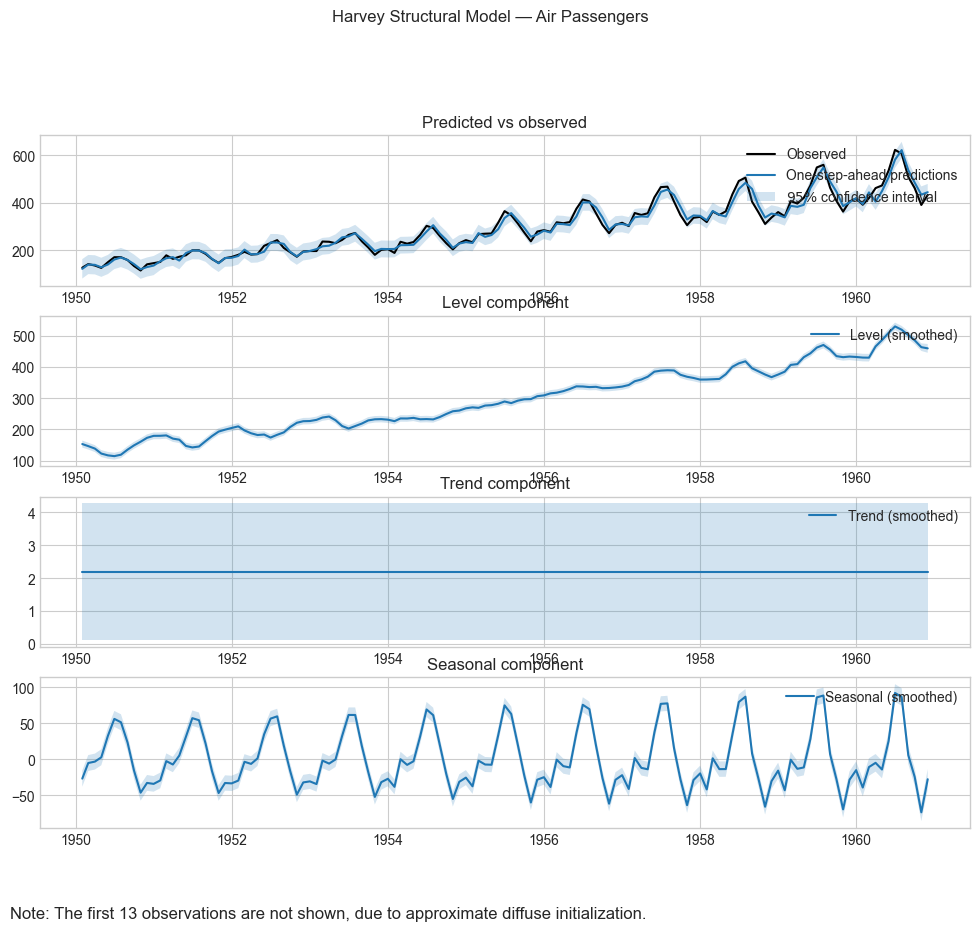

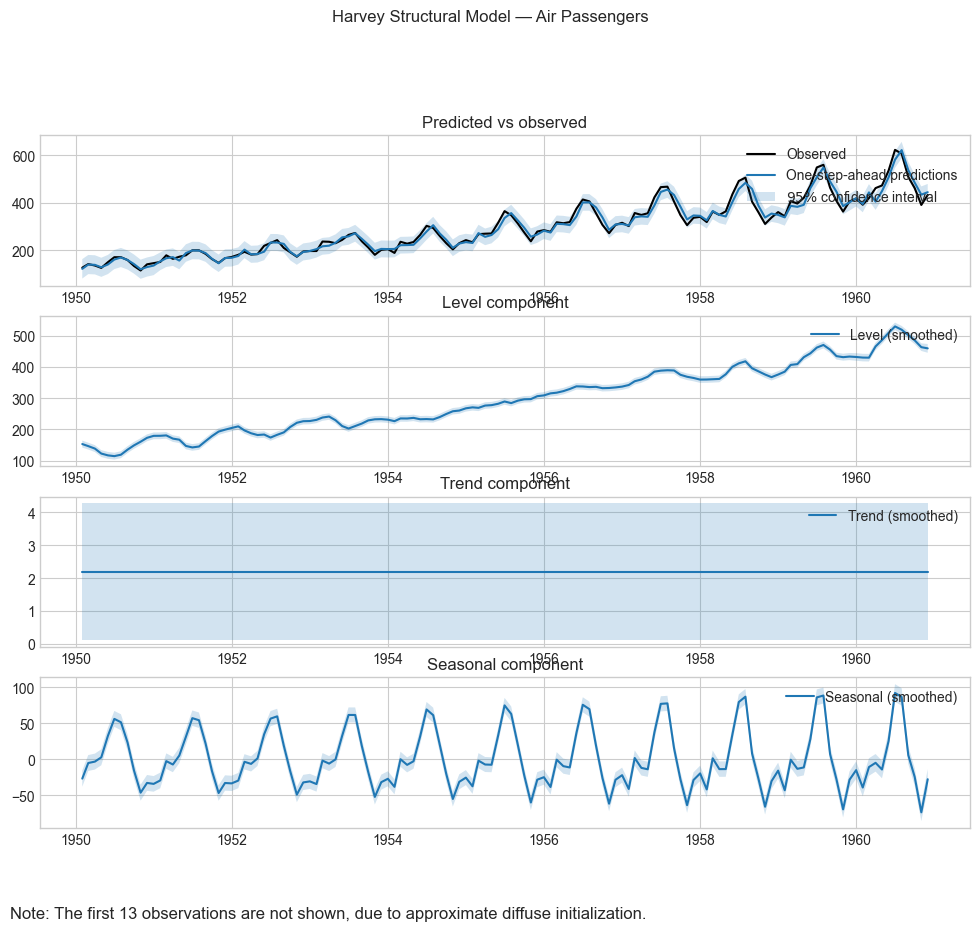

In [3]:

# Extract components
fig = uc_struct.plot_components(figsize=(12, 9))
fig.suptitle('Harvey Structural Model — Air Passengers', y=1.02)
fig


## ARIMA Equivalences

| Structural model | Equivalent ARIMA |
|---|---|
| Local level | ARIMA(0,1,1) |
| Local linear trend | ARIMA(0,2,2) |
| Local level + seasonal(12) | ARIMA(0,1,1)(0,1,1)₁₂ |

Production tools: **KFAS** (R), **statsmodels** (Python), used internally by TRAMO-SEATS and JDemetra+.

## Key Takeaways

- **Interpretability**: Structural models decompose into level, trend, season — unlike black-box ARIMA.
- **Kalman filter**: Optimal recursive estimation under Gaussian linear assumptions.
- **Equivalence**: Many ARIMA models have structural representations — choose based on purpose.
- **Missing data**: State-space handles gaps naturally; ARIMA requires complete series.

---

**Navigation**: [← Previous: SARIMA](06_sarima.ipynb) | [Next: Model Comparison →](08_model_comparison.ipynb)
